35.51451676698195


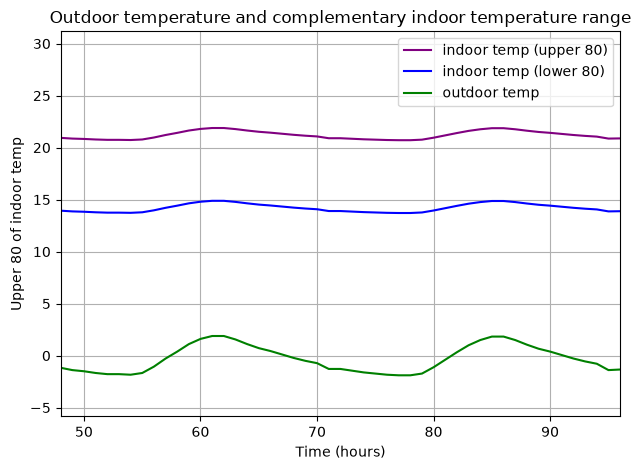

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime

# Process weather file
weather_file = pd.read_csv('boston_weather_2010_hourly_noaa.csv')
outdoor_temp = (weather_file['HLY-TEMP-NORMAL'] - 32) * (5/9) # convert from degrees F to degrees C

# print(outdoor_temp)
upper_80_indoor_temp = (0.31*outdoor_temp) + 21.3
lower_80_indoor_temp = (0.31*outdoor_temp) + 14.3
indoor_air_temp = upper_80_indoor_temp
# print(upper_80_indoor_temp)

# Model Environmental Heat Exchange - sensible and radiative heat losses
timestep = 24 # number of hours we are looking ahead
body_temp_sweat = (0.194/58.15) * (64) + 36.301 - 1
print(body_temp_sweat)

# plotting temperatures below sweat threshold in adaptive model
fig, ax = plt.subplots()
time_hours = np.linspace(0,8759,8759)
ax.plot(time_hours, upper_80_indoor_temp, label='indoor temp (upper 80)', color='purple')
ax.plot(time_hours, lower_80_indoor_temp, label='indoor temp (lower 80)', color='blue')
ax.plot(time_hours, outdoor_temp, label='outdoor temp', color='green')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Upper 80 of indoor temp')
ax.set_title('Outdoor temperature and complementary indoor temperature range')
ax.grid(True)

ax.legend()
plt.xlim(48, 96)
plt.tight_layout()
plt.show()



[36.5 36.5 36.5 ... 36.5 36.5 36.5]
0       30.413953
1       30.394258
2       30.381128
3       30.361432
4       30.348302
          ...    
8754    30.624037
8755    30.584646
8756    30.551820
8757    30.512430
8758    30.486169
Name: HLY-TEMP-NORMAL, Length: 8759, dtype: float64


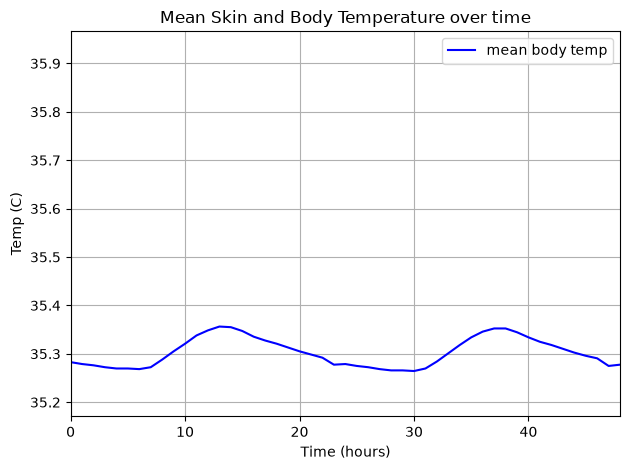

In [ ]:
body_cp = 3500
mean_skin_temp = (0.3812 * (upper_80_indoor_temp)) + 22.406 # get a more accurate model for skin temp
mean_core_temp = np.array([36.5] * len(time_hours))
mean_body_temp = ((0.2*mean_skin_temp) + (0.8*mean_core_temp))
print(mean_core_temp)
print(mean_skin_temp)

body_temp_shiver = 35.2
thermal_flexibility_mean_body_temp = 0.2 # the human body can comfortably increase temperature by about 0.2 degrees before physiological temperature regulation kicks in.

fig, ax = plt.subplots()
ax.plot(time_hours, mean_body_temp, label='mean body temp', color='blue')
#ax.axhspan(body_temp_sweat, 36.1, color='red', alpha=0.2, label='sweating')
#ax.axhspan(35.1, body_temp_shiver, color='blue', alpha=0.2, label='shivering')
# ax.plot(time_hours, mean_skin_temp, label='mean skin temp', color='red')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Temp (C)')
ax.set_title('Mean Skin and Body Temperature over time')
ax.grid(True)

ax.legend()
plt.xlim(0, 48)
plt.tight_layout()
plt.show()




In [5]:
# Heat Storage and Exchange Modeling
# the rate at which you need to transfer heat to the person to get an acceptable increase in intenal temperature

body_cp = 3500
body_mass = 62
average_temp_midpoint = 36.2

#energy_needed = body_cp * body_mass * (body_temp_sweat- average_temp_midpoint)
energy_needed = body_cp * body_mass * thermal_flexibility_mean_body_temp
watts_per_hourly_range = np.empty(6)
for i in range(len(watts_per_hourly_range)) :
    watts_per_hourly_range[i] = energy_needed / ( (i+1) * 3600 )
print(f"Body Specific Heat Capacity: {body_cp} \nAverage Body Mass: {body_mass} \nAverage Body Temp Midpoint {average_temp_midpoint} \nSweat Limit: {body_temp_sweat} \n\nEnergy Needed to Heat Person from midpoint to high range:\n{energy_needed}")
print(f"\nWatts of Heat Stored to raise Mean Body Temp from midpoint to upper range from 1-6hrs:\n{watts_per_hourly_range}")
# this section shows how core and mean body temperature translate to comfortable heat storage capacity and how 
# we might translate that storage capacity to the heat that needs to be exchanged with the environment

Body Specific Heat Capacity: 3500 
Average Body Mass: 62 
Average Body Temp Midpoint 36.2 
Sweat Limit: 35.51451676698195 

Energy Needed to Heat Person from midpoint to high range:
43400.0

Watts of Heat Stored to raise Mean Body Temp from midpoint to upper range from 1-6hrs:
[12.05555556  6.02777778  4.01851852  3.01388889  2.41111111  2.00925926]


In [ ]:
# Rate at which the Body Releases excess stored heat
# It's the same temperature difference - just the opposite direction so the body just needs to release the equivalent amount of Joules. 
# We can't control the rate at which excess watts are lost so much as quantify them through the heat loss relationship below.

## Relating Comfortable Heat Storage and Heat Exchange with the Surrounding Environment

total heat loss from skin: 0       38.191390
1       38.036880
2       37.933870
3       37.779352
4       37.676338
          ...    
8754    39.839247
8755    39.530310
8756    39.272850
8757    38.963883
8758    38.757895
Name: HLY-TEMP-NORMAL, Length: 8759, dtype: float64
total heat loss from respiration: [6.5 6.5 6.5 ... 6.5 6.5 6.5]
total heat transfer: 0       20.308610
1       20.463120
2       20.566130
3       20.720648
4       20.823662
          ...    
8754    18.660753
8755    18.969690
8756    19.227150
8757    19.536117
8758    19.742105
Name: HLY-TEMP-NORMAL, Length: 8759, dtype: float64


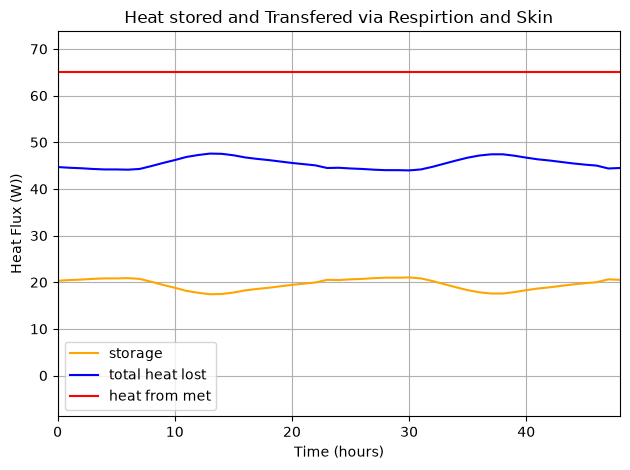

In [ ]:
# Heat Balance Analysis
# HEAT LOSS VIA SKIN
met_rate = 65
work_rate = 0

# relevant temperatures in Kelvins
indoor_air_temp_k = indoor_air_temp + 273.15
mean_skin_temp_k = mean_skin_temp + 273.15
mean_body_temp_k = mean_body_temp + 273.15
mean_core_temp_k = mean_core_temp + 273.15
average_temp_midpoint_k = average_temp_midpoint + 273.15

# convective and radiative
i_clo = 0.61
r_clo = 0.155*i_clo
f_clo = 1.20 # trousers and long sleeved shirt [ASHRAE pg 9.8]
convective_heat_transfer_coefficient = 3.1
linear_radiative_heat_transfer_coefficient = 4.7
htc = convective_heat_transfer_coefficient+linear_radiative_heat_transfer_coefficient
r_c_ht = (mean_skin_temp - indoor_air_temp) / (r_clo + (1/(f_clo*htc)))

# evaporative
skin_wettedness = 0.06 # dry skin
p_sk = np.power(2.718,(77.3450+0.0057*(mean_skin_temp + 273.15)-7235/(mean_skin_temp+273.15)))/(np.power((mean_skin_temp+273.15),8.2))/1000
p_a = np.array([101.325] * len(time_hours)) # Convert p_a to a NumPy array
r_evap_clo = 0.020 # evaporative heat transfer resistance of clothing layer
evap_htc = 2.2 * htc # evaporative heat transfer coefficient [engineering data and measurements]
evap_ht = (skin_wettedness*(p_sk-p_a)) / (r_evap_clo + (1/(f_clo*evap_htc)))

# total heat loss from skin
q_sk = r_c_ht + evap_ht
q_sk = -q_sk

# HEAT LOSS VIA RESPIRATION
c_res = 0.0014 * met_rate * (34 - (indoor_air_temp+273.15))
e_res = 0.0173 * met_rate * (5.87 - p_a)
#e_res = np.array([15] * len(time_hours))
#print(f"c_res: {c_res}")
#print(f"e_res: {e_res}")
#q_res = c_res + e_res
q_res = np.array([met_rate * 0.1] * len(time_hours))

print(f"total heat loss from skin: {q_sk}\ntotal heat loss from respiration: {q_res}")
storage = met_rate - (q_sk + q_res)
#print(f"Storage:{storage}")

total_heat_transfer = met_rate - (q_sk + q_res)
print(f"total heat transfer: {total_heat_transfer}")

# graphing again!
fig, ax = plt.subplots() 
ax.plot(time_hours, storage, label='storage', color='orange')
ax.plot(time_hours, (q_sk+q_res), label='total heat lost', color='blue')
#ax.plot(time_hours, q_sk, label='heat loss from skin', color='blue')
#ax.plot(time_hours, q_res, label='heat loss from respiration', color='green')
ax.plot(time_hours, np.array([met_rate] * len(time_hours)), label='heat from met', color='red')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Heat Flux (W/m^2))')
ax.set_title('Heat stored and Transfered via Respirtion and Skin')
ax.grid(True)

ax.legend()
plt.xlim(0, 48)
plt.tight_layout()
plt.show()



# determining Pre-Heating vs. Pre-Cooling and Watt-Hour demand

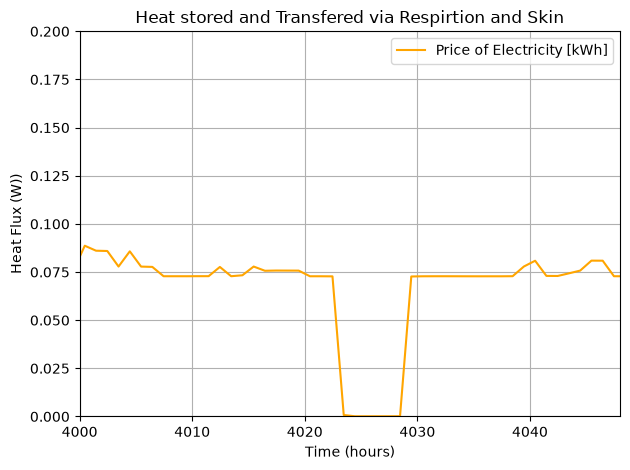

In [27]:
# Price Curve Data Processing
# The price file contains the price of electricity in a 3-node demand system in $/MWh - each column is 1 node

# File Processing
price_file = pd.read_csv('price.csv')
electricity_price = price_file['x3'] / 1000 # [#/kWh]

# Graphing Hourly Price over a year
fig, ax = plt.subplots()
price_model_time_hours = np.linspace(0, len(electricity_price), len(electricity_price))
ax.plot(price_model_time_hours, electricity_price, label='Price of Electricity [kWh]', color='orange')
# ax.axhspan(body_temp_sweat, 36.1, color='red', alpha=0.2, label='Pre-Heating Condition')
# ax.axhspan(body_temp_sweat, 36.1, color='blue', alpha=0.2, label='Pre-Cooling Condition')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Heat Flux (W))')
ax.set_title('Heat stored and Transfered via Respirtion and Skin')
ax.grid(True)

ax.legend()
plt.xlim(4000, 4048)
plt.ylim(0, 0.2)
plt.tight_layout()
plt.show() 


# Pre-Heating Analysis - Attempt 1
